In [439]:
import plotly.io as pio
#
try:
    import kaleido
    pio.renderers.default = "png"
except ImportError:
    print("Install kaleido: pip install kaleido")
    pio.renderers.default = "svg"
#
# # Force PNG rendering for GitHub compatibility
# pio.renderers.default = "png"
# pio.templates.default = "plotly_dark"
#
# # Set both template AND kaleido engine settings
for template in ["plotly", "plotly_dark", "plotly_white"]:
    pio.templates[template].layout.update(
        # width=1750,
        # height=600,
        # font=dict(size=14),
        # title_x=0.5,
        paper_bgcolor='#1e1e1e',
        plot_bgcolor='#1e1e1e',
        font_color='white'
    )
#
# # Set PNG export settings
pio.kaleido.scope.default_width = 1750
pio.kaleido.scope.default_height = 600
# pio.kaleido.scope.default_scale = 1

/tmp/ipykernel_6913/952015465.py:27: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.


/tmp/ipykernel_6913/952015465.py:28: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.




In [494]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
stores = pd.read_csv('stores.csv')
transactions = pd.read_csv('transactions.csv')
holidays = pd.read_csv('holidays_events.csv')
oil = pd.read_csv('oil.csv')

In [495]:
train['test'] = 0
test['test'] = 1

data = pd.concat([train, test], axis=0)

data = data.merge(holidays, on='date', how='left')
data = data.merge(stores, on='store_nbr', how='left')
data = data.merge(oil, on='date', how='left')
data = data.merge(transactions, on=['date', 'store_nbr'], how='left')
data = data.set_index(['store_nbr', 'date', 'family'])
data = data.drop(index='2013-01-01', level=1)
display(data)

id   sales  onpromotion  \
store_nbr date       family                                                     
1         2013-01-02 AUTOMOTIVE                     1782     2.0            0   
                     BABY CARE                      1783     0.0            0   
                     BEAUTY                         1784     2.0            0   
                     BEVERAGES                      1785  1091.0            0   
                     BOOKS                          1786     0.0            0   
...                                                  ...     ...          ...   
9         2017-08-31 POULTRY                     3029395     NaN            1   
                     PREPARED FOODS              3029396     NaN            0   
                     PRODUCE                     3029397     NaN            1   
                     SCHOOL AND OFFICE SUPPLIES  3029398     NaN            9   
                     SEAFOOD                     3029399     NaN            0   

                                                 test type_x locale  \
store_nbr date       family                                           
1         2013-01-02 AUTOMOTIVE                     0    NaN    NaN   
                     BABY CARE                      0    NaN    NaN   
                     BEAUTY                         0    NaN    NaN   
                     BEVERAGES                      0    NaN    NaN   
                     BOOKS                          0    NaN    NaN   
...                                               ...    ...    ...   
9         2017-08-31 POULTRY                        1    NaN    NaN   
                     PREPARED FOODS                 1    NaN    NaN   
                     PRODUCE                        1    NaN    NaN   
                     SCHOOL AND OFFICE SUPPLIES     1    NaN    NaN   
                     SEAFOOD                        1    NaN    NaN   

                                                locale_name description  \
store_nbr date       family                                               
1         2013-01-02 AUTOMOTIVE                         NaN         NaN   
                     BABY CARE                          NaN         NaN   
                     BEAUTY                             NaN         NaN   
                     BEVERAGES                          NaN         NaN   
                     BOOKS                              NaN         NaN   
...                                                     ...         ...   
9         2017-08-31 POULTRY                            NaN         NaN   
                     PREPARED FOODS                     NaN         NaN   
                     PRODUCE                            NaN         NaN   
                     SCHOOL AND OFFICE SUPPLIES         NaN         NaN   
                     SEAFOOD                            NaN         NaN   

                                                transferred   city      state  \
store_nbr date       family                                                     
1         2013-01-02 AUTOMOTIVE                         NaN  Quito  Pichincha   
                     BABY CARE                          NaN  Quito  Pichincha   
                     BEAUTY                             NaN  Quito  Pichincha   
                     BEVERAGES                          NaN  Quito  Pichincha   
                     BOOKS                              NaN  Quito  Pichincha   
...                                                     ...    ...        ...   
9         2017-08-31 POULTRY                            NaN  Quito  Pichincha   
                     PREPARED FOODS                     NaN  Quito  Pichincha   
                     PRODUCE                            NaN  Quito  Pichincha   
                     SCHOOL AND OFFICE SUPPLIES         NaN  Quito  Pichincha   
                     SEAFOOD                            NaN  Quito  Pichincha   

                                              

In [442]:
data_ = data.copy().reset_index()

train = data_[data_['test'] == 0]
test = data_[data_['test'] == 1]

train['date'] = pd.to_datetime(train["date"])
train['day_of_week'] = train['date'].dt.day_of_week
train['day_of_year'] = train['date'].dt.dayofyear
train['day_of_month'] = train['date'].dt.day
train['month'] = train['date'].dt.month
train['quarter'] = train['date'].dt.quarter
train['year'] = train['date'].dt.year

/tmp/ipykernel_6913/1357458643.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_6913/1357458643.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_6913/1357458643.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_6913

In [443]:
train['date'] = pd.to_datetime(train.date)
test['date'] = pd.to_datetime(test.date)
transactions['date'] = pd.to_datetime(transactions.date)
oil['date'] = pd.to_datetime(oil.date)
holidays['date'] = pd.to_datetime(holidays.date)

/tmp/ipykernel_6913/640243689.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_6913/640243689.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [444]:
family_list = train['family'].unique()
store_list = stores['store_nbr'].unique()

display(family_list)
display(store_list)

array(['AUTOMOTIVE', 'BABY CARE', 'BEAUTY', 'BEVERAGES', 'BOOKS',
       'BREAD/BAKERY', 'CELEBRATION', 'CLEANING', 'DAIRY', 'DELI', 'EGGS',
       'FROZEN FOODS', 'GROCERY I', 'GROCERY II', 'HARDWARE',
       'HOME AND KITCHEN I', 'HOME AND KITCHEN II', 'HOME APPLIANCES',
       'HOME CARE', 'LADIESWEAR', 'LAWN AND GARDEN', 'LINGERIE',
       'LIQUOR,WINE,BEER', 'MAGAZINES', 'MEATS', 'PERSONAL CARE',
       'PET SUPPLIES', 'PLAYERS AND ELECTRONICS', 'POULTRY',
       'PREPARED FOODS', 'PRODUCE', 'SCHOOL AND OFFICE SUPPLIES',
       'SEAFOOD'], dtype=object)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54])

/tmp/ipykernel_6913/3128328506.py:12: FutureWarning:

ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


/tmp/ipykernel_6913/3128328506.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the doc

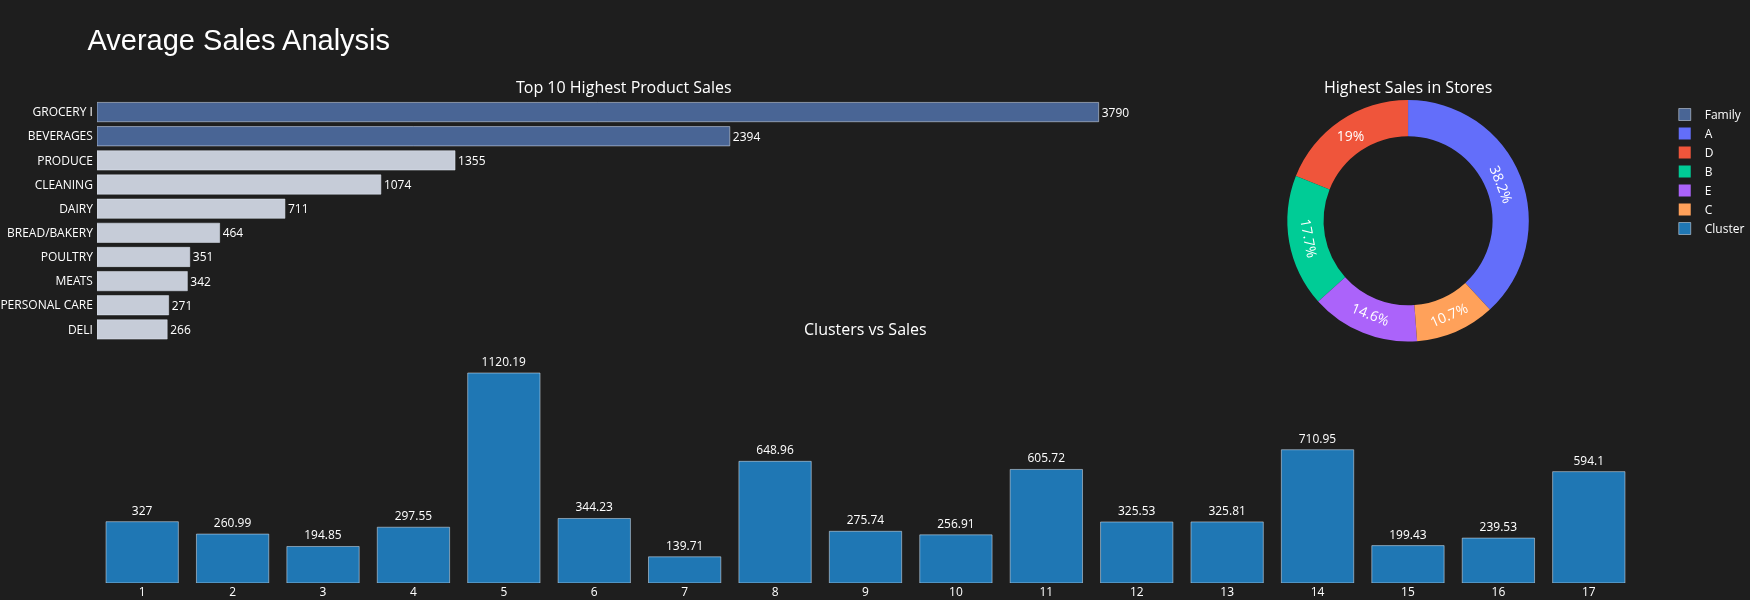

In [445]:
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import plotly.express as px

# data
df_st_sa = sales[:train.shape[0]].groupby('store_type').agg({"sales" : "mean"}).reset_index().sort_values(by='sales', ascending=False)
df_fa_sa = sales[:train.shape[0]].groupby('family').agg({"sales" : "mean"}).reset_index().sort_values(by='sales', ascending=False)[:10]
df_cl_sa = sales[:train.shape[0]].groupby('cluster').agg({"sales" : "mean"}).reset_index() 

# chart color
df_fa_sa['color'] = '#496595'
df_fa_sa['color'][2:] = '#c6ccd8'
df_cl_sa['color'] = '#1f77b4'  # Better contrast for dark theme

# chart
fig = make_subplots(rows=2, cols=2, 
                    specs=[[{"type": "bar"}, {"type": "pie"}],
                           [{"colspan": 2}, None]],
                    column_widths=[0.7, 0.3], vertical_spacing=0, horizontal_spacing=0.02,
                    subplot_titles=("Top 10 Highest Product Sales", "Highest Sales in Stores", "Clusters vs Sales"))

# Top 10 highest product sales bars with values
fig.add_trace(go.Bar(
    x=df_fa_sa['sales'], y=df_fa_sa['family'], marker=dict(color=df_fa_sa['color']),
    name='Family', orientation='h',
    text=round(df_fa_sa['sales']), textposition='outside',
    textfont=dict(color='white', size=12)  # White text for dark background
), row=1, col=1)

# Pie chart with percentages inside
fig.add_trace(go.Pie(
    values=df_st_sa['sales'], labels=df_st_sa['store_type'], name='Store type',
    hole=0.7,
    hoverinfo='label+percent+value', textinfo='percent',
    textposition='inside',
    textfont=dict(color='white', size=14)  # White text for pie chart
), row=1, col=2)

# Clusters vs sales bar chart with values above bars
fig.add_trace(go.Bar(
    x=df_cl_sa['cluster'], y=df_cl_sa['sales'], 
    name='Cluster', marker=dict(color=df_cl_sa['color']),
    text=df_cl_sa['sales'].round(2), textposition='outside',
    textfont=dict(color='white', size=12)  # White text for dark background
), row=2, col=1)

# styling
fig.update_yaxes(showgrid=False, ticksuffix=' ', categoryorder='total ascending', row=1, col=1)
fig.update_xaxes(visible=False, row=1, col=1)
fig.update_xaxes(tickmode = 'array', tickvals=df_cl_sa.cluster, ticktext=[i for i in range(1,17)], row=2, col=1)
fig.update_yaxes(visible=False, row=2, col=1)
# Fix y-axis range for cluster chart to show text above bars
max_cluster_sales = df_cl_sa['sales'].max()
fig.update_yaxes(range=[0, max_cluster_sales * 1.15], row=2, col=1)

fig.update_layout(
    height=500, bargap=0.2,
    margin=dict(b=0,r=20,l=20), xaxis=dict(tickmode='linear'),
    title_text="Average Sales Analysis",
    title_font=dict(size=29, color='white', family="Lato, sans-serif"),  # White title
    font=dict(color='white', size=12),  # White font for all text
    paper_bgcolor='#1e1e1e',  # Dark background
    plot_bgcolor='#1e1e1e',   # Dark plot area
    hoverlabel=dict(bgcolor="#333333", font_size=10, font_family="Lato, sans-serif"),
    showlegend=True
)

# Update subplot title colors
fig.update_annotations(font_color="white")

fig.show()

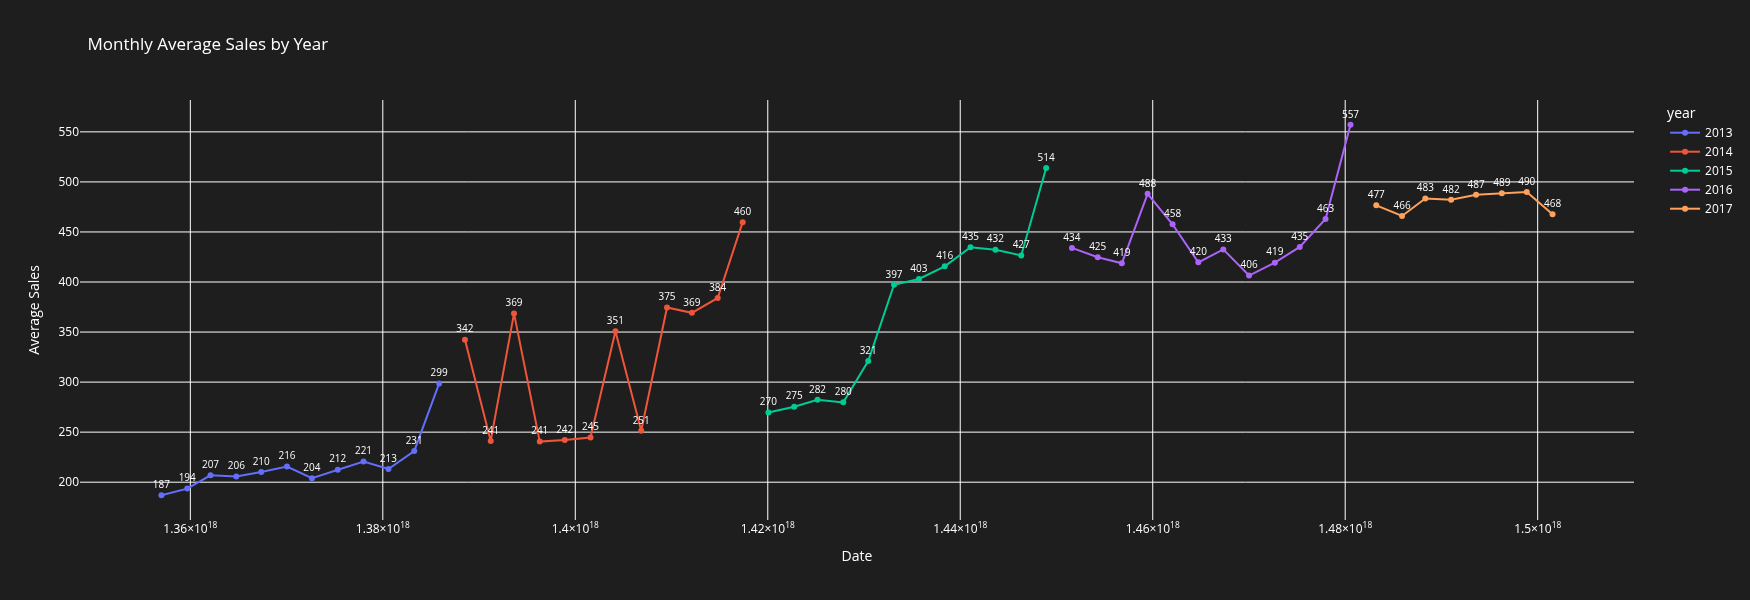

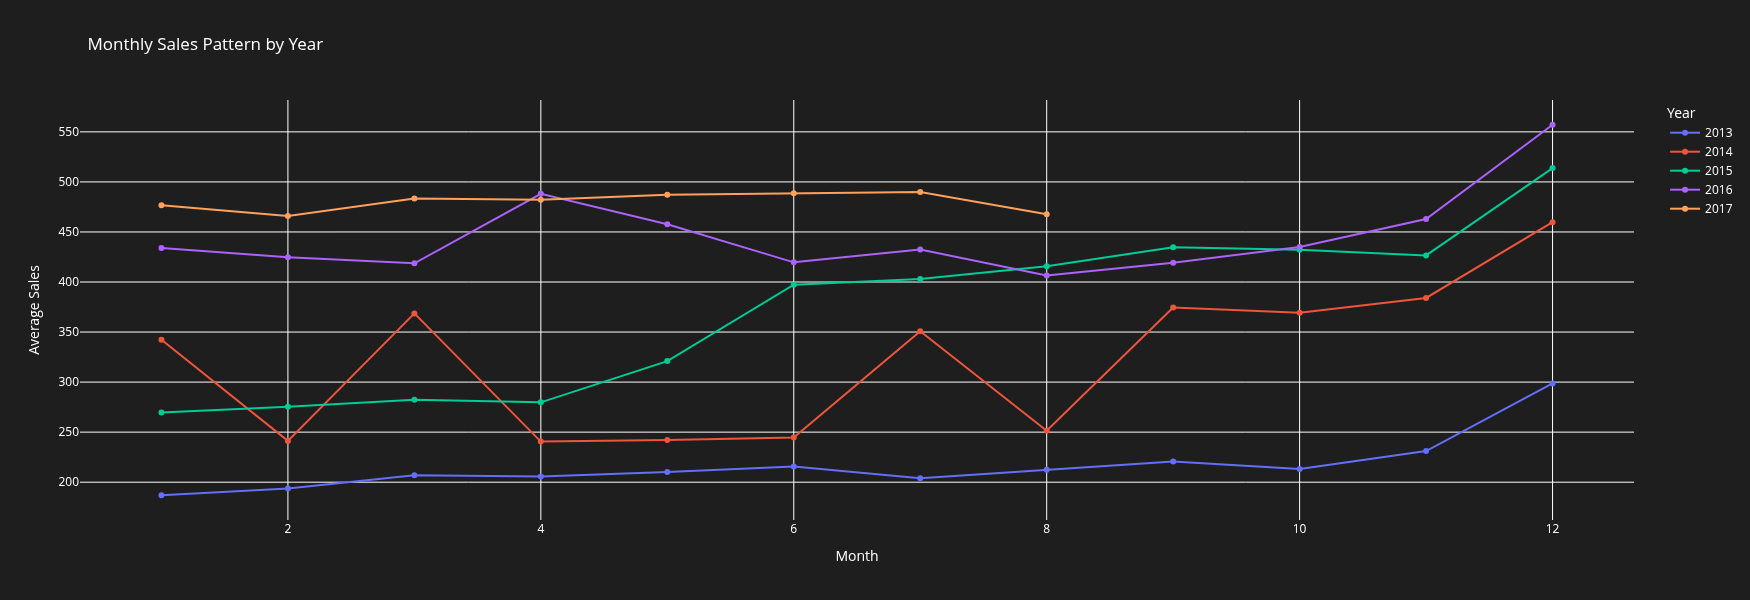

In [446]:
# Much simpler data preparation
sales_clean = sales[:train.shape[0]].copy()
sales_clean['date'] = pd.to_datetime(sales_clean[['year', 'month']].assign(day=1))

# Group by month-year and calculate mean
monthly_sales = sales_clean.groupby(['year', 'month'])['sales'].mean().reset_index()
monthly_sales['date'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))

# Create the plot with values
fig = px.line(monthly_sales, 
              x='date', 
              y='sales', 
              color='year',
              markers=True,
              title='Monthly Average Sales by Year',)

# Add values on hover and customize
fig.update_traces(
    mode='lines+markers+text',
    textposition='top center',
    texttemplate='%{y:.0f}',
    textfont_size=10
)

fig.update_layout(
    xaxis_title='Date',
    yaxis_title='Average Sales',
    hovermode='x unified',
    font=dict(color='white')
)

fig.show()

# Alternative: Even simpler with pivot for better visualization
pivot_data = monthly_sales.pivot(index='month', columns='year', values='sales')

fig2 = px.line(pivot_data, 
               title='Monthly Sales Pattern by Year',
               markers=True)

fig2.update_traces(mode='lines+markers')
fig2.update_layout(
    xaxis_title='Month',
    yaxis_title='Average Sales',
    legend_title='Year'
)

fig2.show()

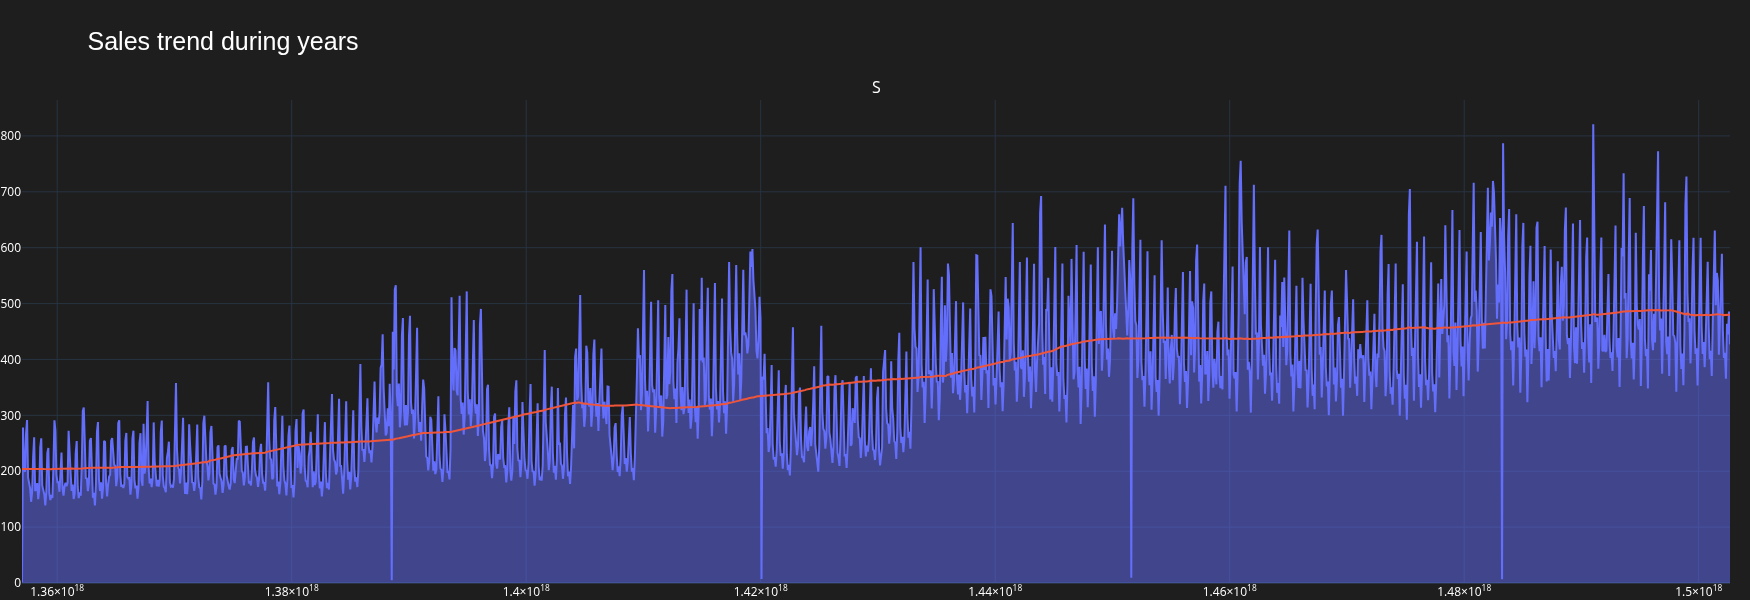

In [447]:
sales_during_year = sales[:train.shape[0]].groupby('date').agg({"sales" : "mean"}).reset_index()
sales_during_year.set_index('date',inplace=True)
moving_average = sales_during_year.rolling(
    window=365,       # 365-day window
    center=True,      # puts the average at the center of the window
    min_periods=183,  # choose about half the window size
).mean()              # compute the mean (could also do median, std, min, max, ...)
moving_average['date'] = sales_during_year.index

fig = make_subplots(rows=1, cols=1, vertical_spacing=0.08,                    
                    subplot_titles=("Sales 365 - Day Moving Average"))
fig.add_trace(go.Scatter(x=sales_during_year.index, y=sales_during_year['sales'],
                         mode='lines', fill='tozeroy',
                         name='365-Day Moving Average'))
fig.add_trace(go.Scatter(x=moving_average.date,y=moving_average.sales,mode='lines',name='Trend'))
fig.update_layout(height=350, bargap=0.15,
                  margin=dict(b=0,r=20,l=20), 
                  title_text="Sales trend during years",
                  template="plotly_dark",
                  title_font=dict(size=25, family="Lato, sans-serif"),
                  font=dict(color='white'),
                  hoverlabel=dict(font_size=13, font_family="Lato, sans-serif"),
                  showlegend=False)

fig.show()

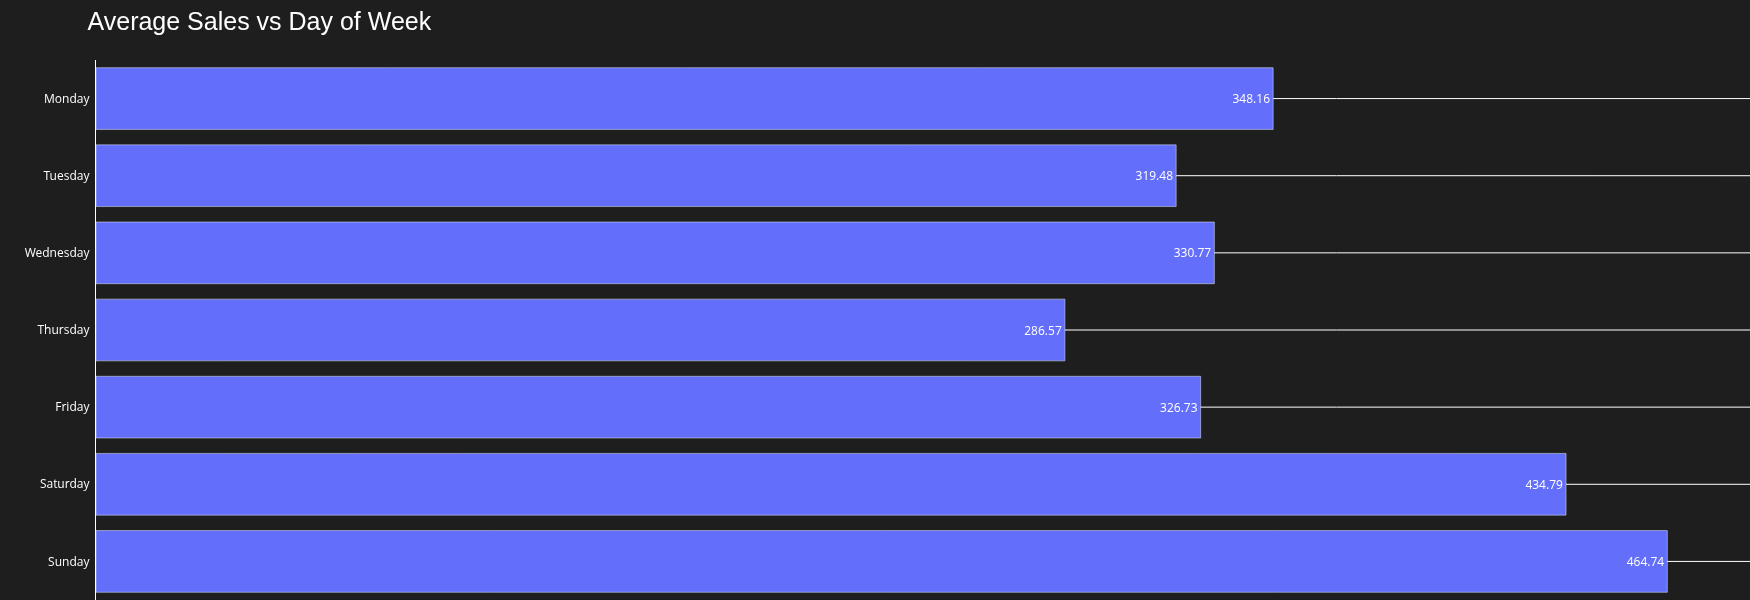

In [448]:
df_dw_sa = sales[:train.shape[0]].groupby('day_of_week').agg({"sales" : "mean"}).reset_index()
df_dw_sa.sales = round(df_dw_sa.sales, 2)

# chart
fig = px.bar(df_dw_sa, y='day_of_week', x='sales', title='Average Sales vs Day of Week',
             color_discrete_sequence=['dark blue'], text='sales',
             category_orders=dict(day_of_week=["Monday","Tuesday","Wednesday","Thursday", "Friday","Saturday","Sunday"]))
fig.update_yaxes(showgrid=True, ticksuffix=' ', showline=True)
fig.update_xaxes(visible=False)
fig.update_layout(margin=dict(t=60, b=0, l=0, r=0), height=350,
                  hovermode="y unified", 
                  yaxis_title=" ",
                  title_font=dict(size=25, color='white', family="Lato, sans-serif"),
                  font=dict(color='white'),
                  hoverlabel=dict(bgcolor="#333333", font_size=13, font_family="Lato, sans-serif"))
fig.show()

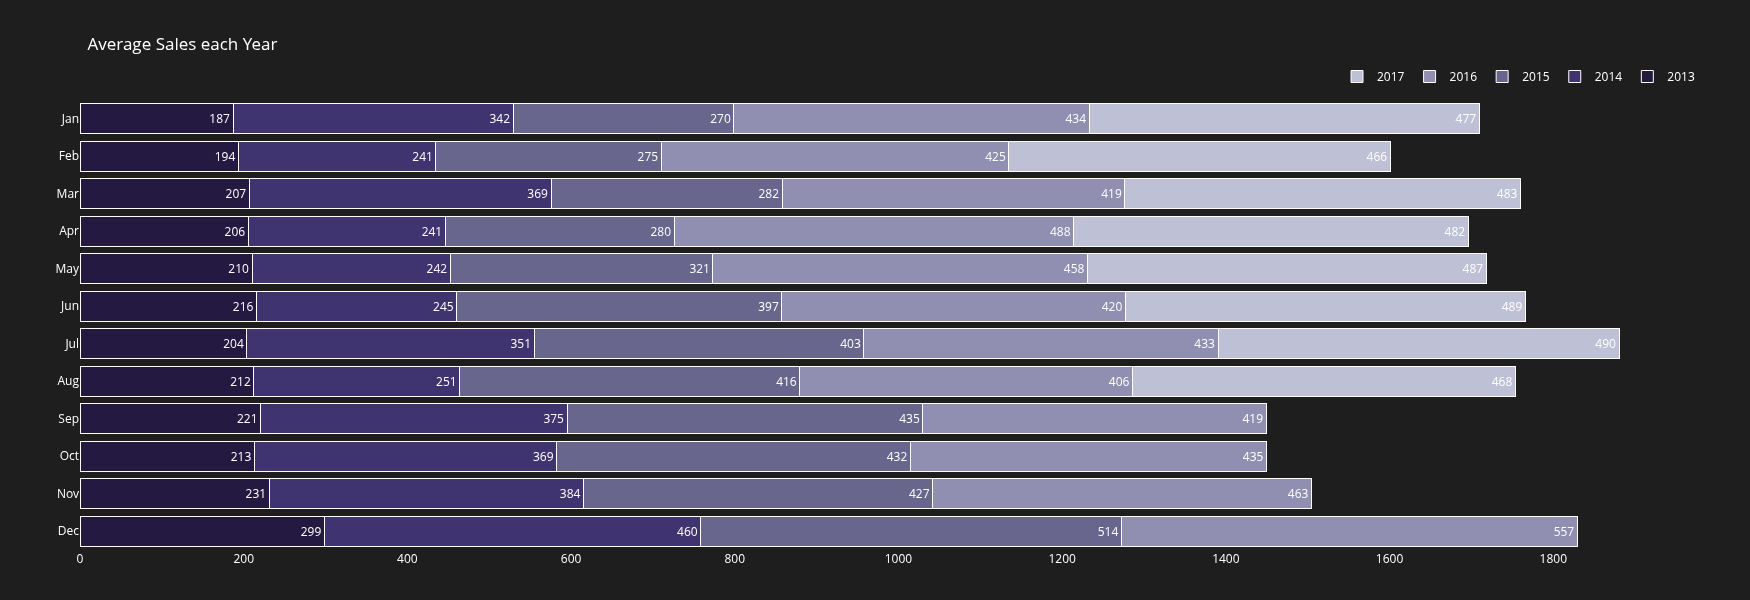

In [449]:
# Simplified data preparation - one line instead of 10+
sales_data = sales[:train.shape[0]].groupby(['year', 'month'])['sales'].mean().unstack(level=0).fillna(0)

# Setup
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
years = ['2013', '2014', '2015', '2016', '2017']
colors = ['rgba(38, 24, 74, 0.8)', 'rgba(71, 58, 131, 0.8)',
          'rgba(122, 120, 168, 0.8)', 'rgba(164, 163, 204, 0.85)',
          'rgba(190, 192, 213, 1)']

fig = go.Figure()

# Add bars for each year
for i, year in enumerate([2013, 2014, 2015, 2016, 2017]):
    if year in sales_data.columns:
        values = sales_data[year].values
    else:
        values = np.zeros(12)
    
    fig.add_trace(go.Bar(
        x=values, 
        y=months,
        orientation='h',
        name=years[i],
        marker=dict(color=colors[i], line=dict(color='white', width=1)),
        text=[f'{v:.0f}' if v > 0 else '' for v in values],  # Add values inside bars
        textposition='inside',
        textfont=dict(color='white', size=12)
    ))

fig.update_layout(
    title='Average Sales each Year',
    xaxis=dict(showgrid=False, zeroline=False),
    yaxis=dict(showgrid=False, categoryorder='array', categoryarray=months[::-1]),
    barmode='stack',
    template="plotly_dark",
    margin=dict(l=80, r=50, t=100, b=50),
    showlegend=True,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    font=dict(color='white'),
    height=600
)

fig.show()

In [450]:
store_sales = pd.merge(train.groupby(['date', 'store_nbr']).sales.sum().reset_index(), transactions, how='left')
store_sales

,date,store_nbr,sales,transactions
0,2013-01-02,1,7417.148000,2111.0
1,2013-01-02,2,10266.718981,2358.0
2,2013-01-02,3,24060.348000,3487.0
3,2013-01-02,4,10200.083980,1922.0
4,2013-01-02,5,10598.619020,1903.0
...,...,...,...,...
90877,2017-08-15,50,16879.121004,2804.0
90878,2017-08-15,51,20154.559000,1573.0
90879,2017-08-15,52,18600.046000,2255.0
90880,2017-08-15,53,8208.189000,932.0


In [451]:
store_sales = store_sales[store_sales['date'] != '2013-01-01']

Spearman Correlation between Total Sales and Transaction: 
---------------------------------------------------------
store_nbr       0.079404
sales           1.000000
transactions    0.809488
Name: sales, dtype: float64


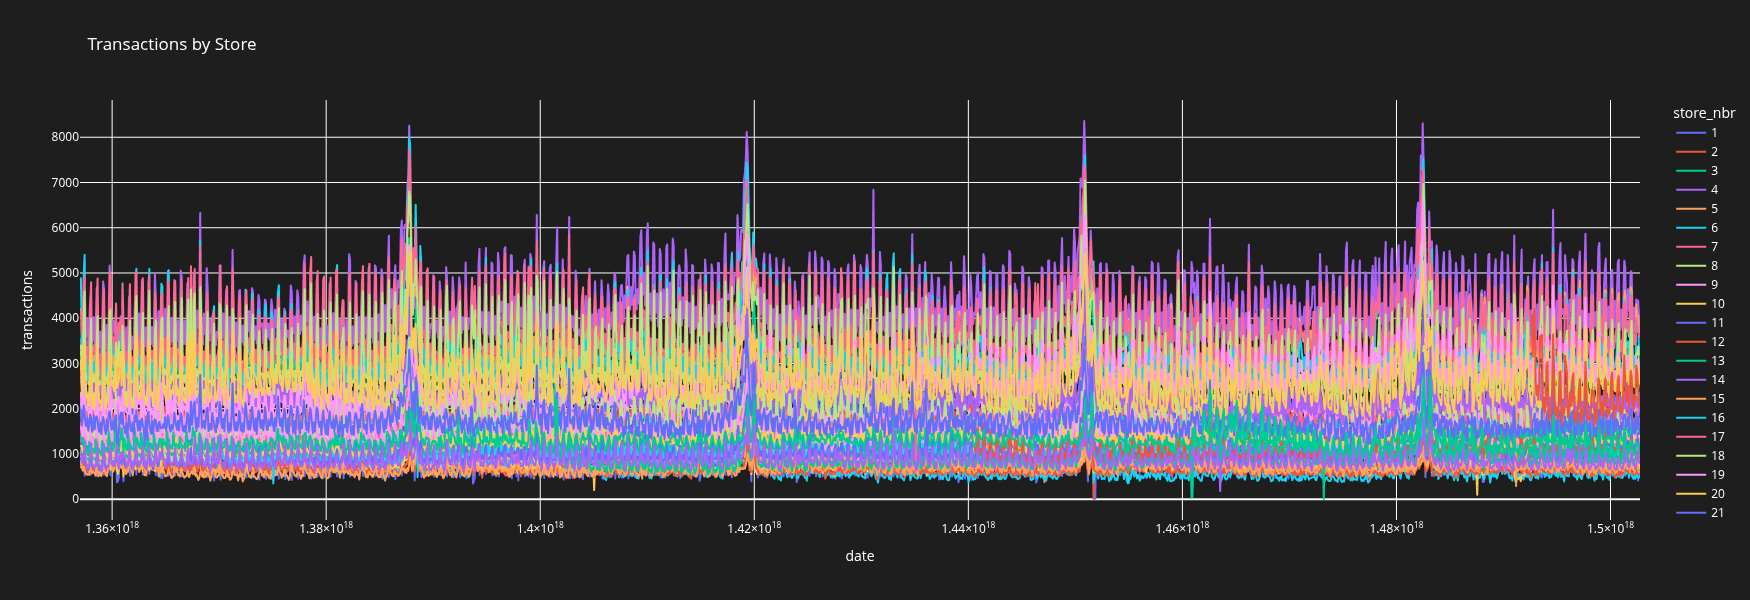

In [452]:
corr_value = store_sales.corr('spearman').sales.drop('date')
print(f'Spearman Correlation between Total Sales and Transaction: \n{'-'*57}\n{corr_value}')

fig = px.line(transactions.sort_values(['store_nbr', 'date']), x='date', y='transactions',
        color='store_nbr', title='Transactions by Store')

fig.show()

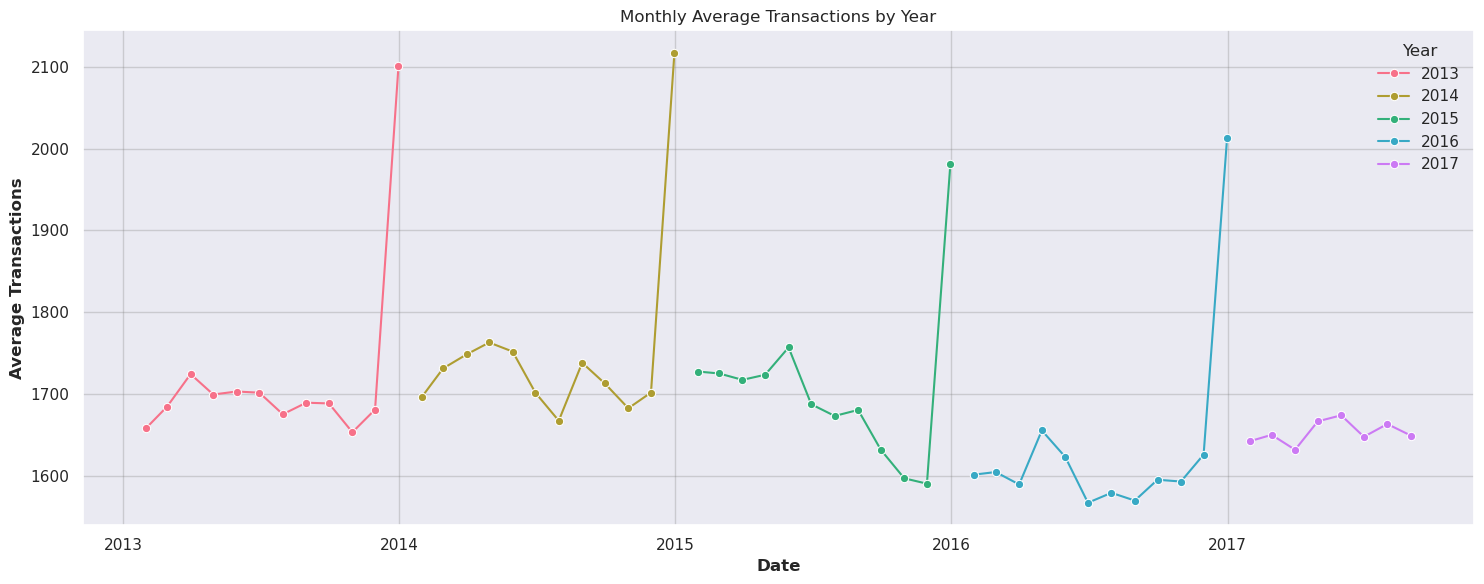

In [453]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')
# plt.style.use('dark_background')

plt.figure(figsize=(15,6))

# Compute monthly average transactions, grouped by month end
monthly_avg_transactions = transactions.set_index('date').resample('ME').transactions.mean().reset_index()
monthly_avg_transactions['year'] = monthly_avg_transactions.date.dt.year

# Plot monthly average transactions with lines by year
color = sns.color_palette('husl', 5)
sns.lineplot(data=monthly_avg_transactions,
             x='date', y='transactions', hue='year', marker='o', palette=color)

plt.title('Monthly Average Transactions by Year')
plt.xlabel('Date')
plt.ylabel('Average Transactions')
plt.legend(title='Year')
plt.grid(True, color='grey', alpha=0.3)
plt.tight_layout()
plt.show()

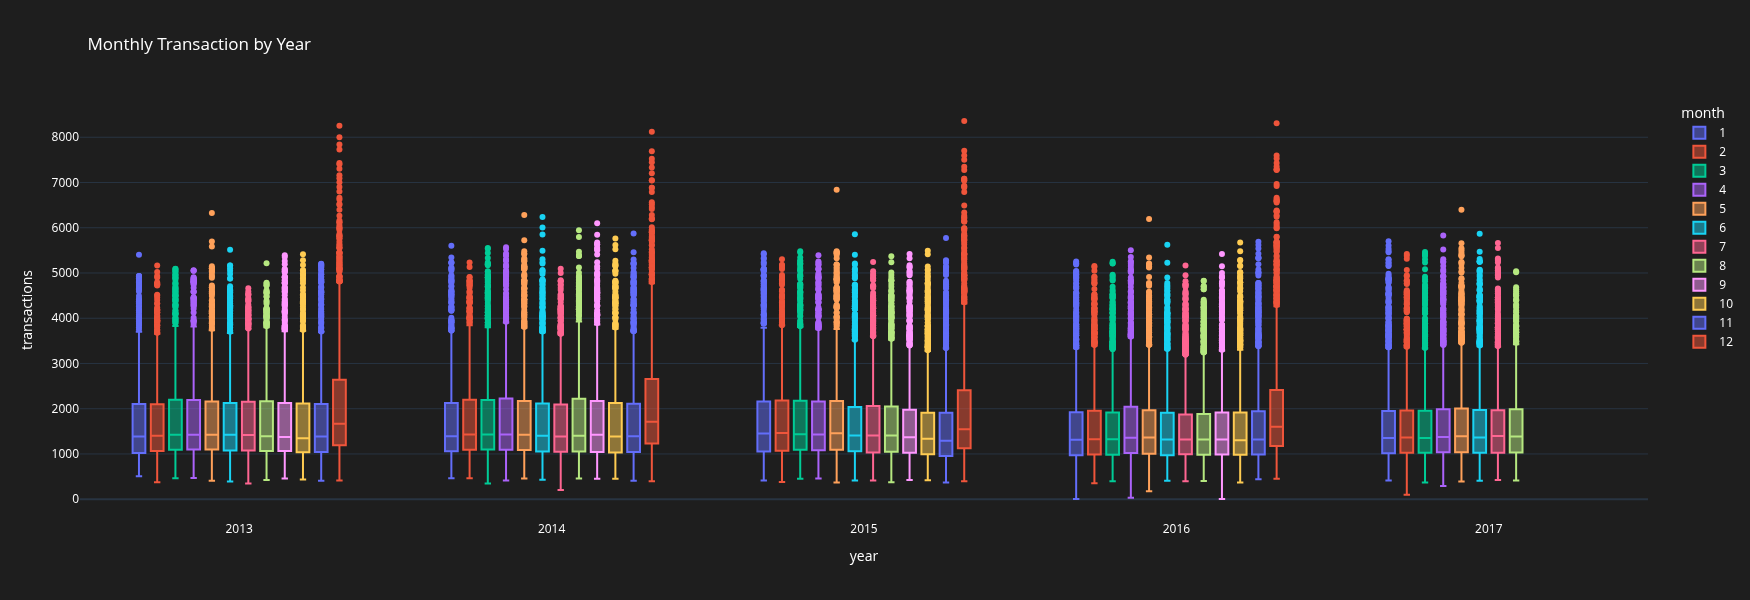

In [454]:
yearly_transactions = transactions.copy()
yearly_transactions['year'] = yearly_transactions.date.dt.year
yearly_transactions['month'] = yearly_transactions.date.dt.month

fig = px.box(yearly_transactions,
       x='year', y='transactions',
       color='month', title='Monthly Transaction by Year', template='plotly_dark')
fig.show()

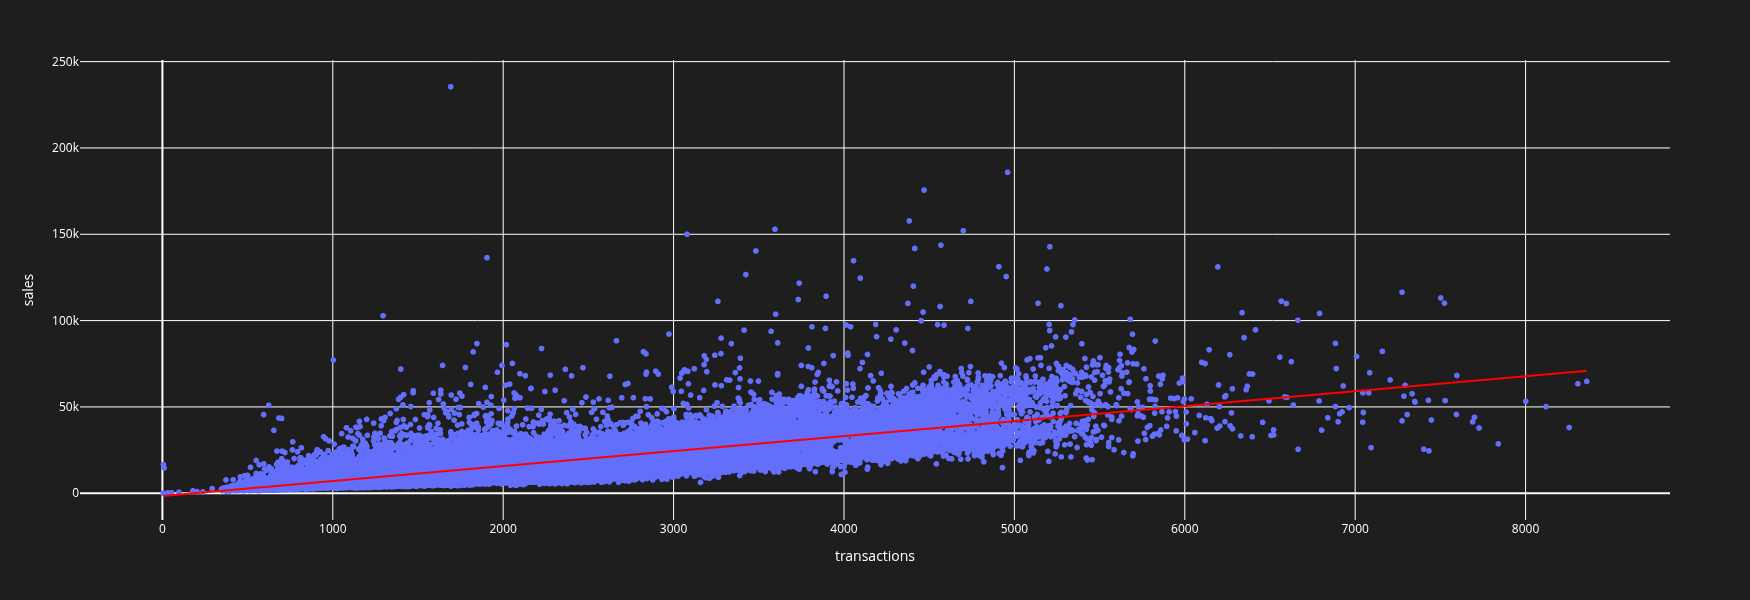

In [455]:
fig = px.scatter(store_sales, x='transactions', y='sales', trendline='ols', trendline_color_override='red')
fig.show()

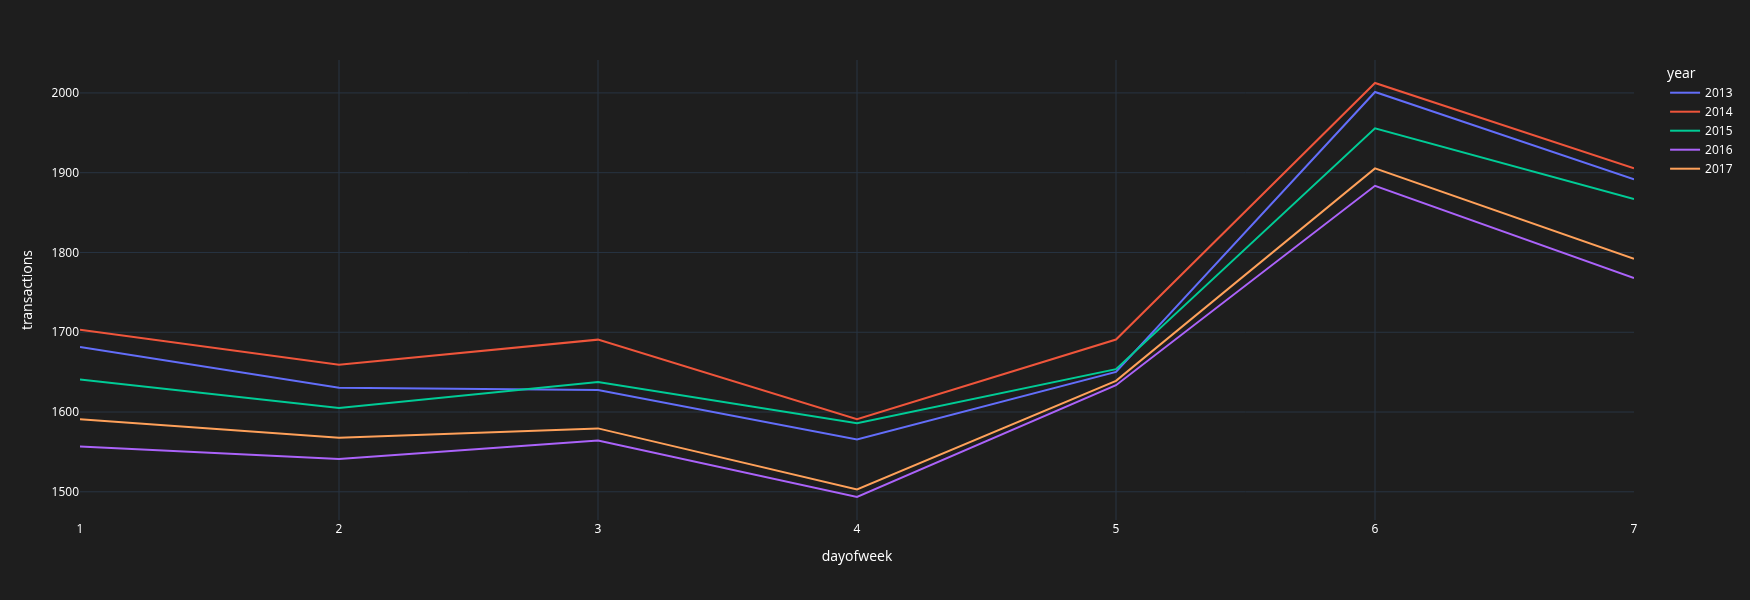

In [456]:
day_of_week_transactions = transactions.copy()
day_of_week_transactions['year'] = day_of_week_transactions.date.dt.year
day_of_week_transactions['dayofweek'] = day_of_week_transactions.date.dt.dayofweek+1
day_of_week_transactions = day_of_week_transactions.groupby(['year', 'dayofweek']).transactions.mean().reset_index()
fig = px.line(day_of_week_transactions,
        x='dayofweek', y='transactions',
        color='year', template='plotly_dark')
fig.show()

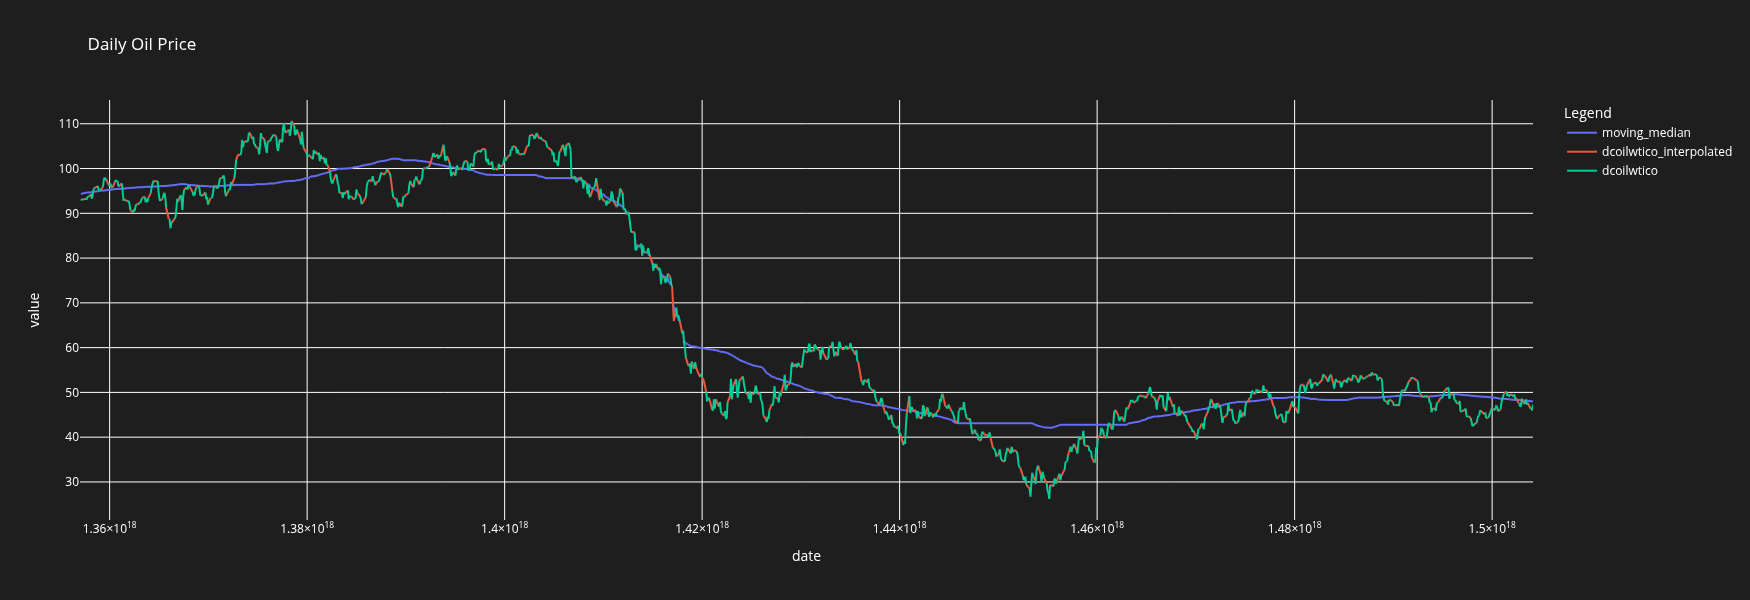

In [457]:
import numpy as np

daily_oil = oil.set_index('date').dcoilwtico.resample('D').sum().reset_index()
daily_oil['dcoilwtico'] = np.where(daily_oil['dcoilwtico'] == 0, np.nan, daily_oil['dcoilwtico'])
daily_oil['dcoilwtico_interpolated'] = daily_oil.dcoilwtico.interpolate()

# Assuming daily_oil is already created and interpolated
daily_oil['moving_median'] = daily_oil['dcoilwtico_interpolated'].rolling(
    window=365, center=True, min_periods=183).median()

oil_plot = daily_oil.melt(id_vars=['date']+list(oil.keys()[5:]), var_name='Legend')
fig = px.line(oil_plot.sort_values(['Legend', 'date'], ascending=[False, True]), x='date', y='value',
        color='Legend', title='Daily Oil Price')
fig.show()

Correlation with Daily Oil Price:
---------------------------------
sales          -0.30
transactions    0.04
Name: dcoilwtico_interpolated, dtype: float64


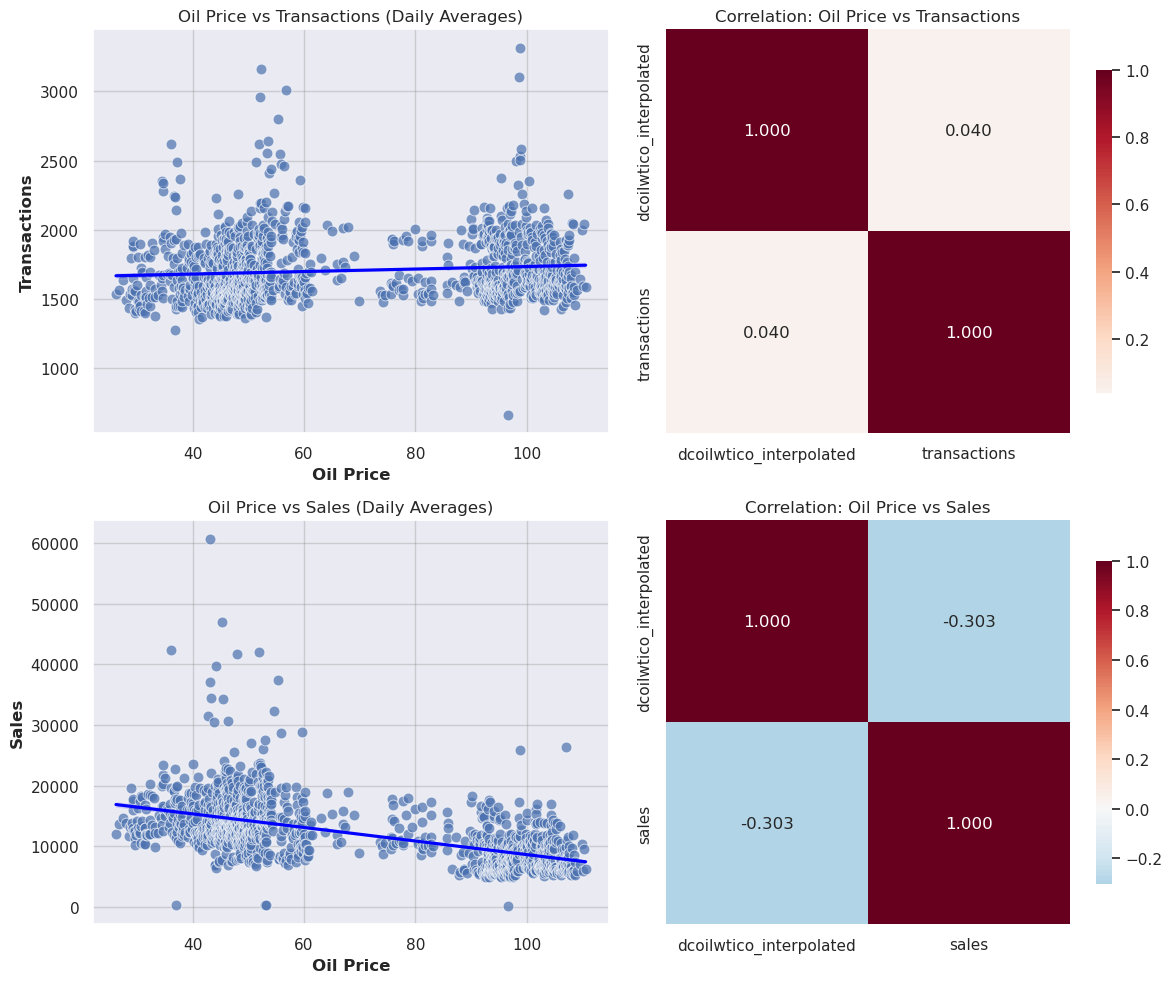

In [458]:
oil_with_daily_price = pd.merge(store_sales, daily_oil, how='left')
print('Correlation with Daily Oil Price:')
print('-'*33)
print(oil_with_daily_price.drop(['store_nbr', 'dcoilwtico'], axis=1).corr('spearman').dcoilwtico_interpolated.loc[['sales', 'transactions']].round(2))

# Aggregate data by oil price bins for cleaner visualization
# oil_with_daily_price['oil_price_bins'] = pd.cut(oil_with_daily_price['dcoilwtico_interpolated'], 
#                                                 bins=20, labels=False)

# Daily aggregated data
daily_agg = oil_with_daily_price.groupby('dcoilwtico_interpolated').agg({
    'sales': 'mean',
    'transactions': 'mean'
}).reset_index()

# Aggregated scatter plot with trend lines
sns.set_style('darkgrid')
# plt.style.use('dark_background')
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
color = sns.color_palette('Spectral', as_cmap=True)

# Plot 1: Transactions vs Oil Price (top left)
sns.scatterplot(data=daily_agg, x='dcoilwtico_interpolated', y='transactions', 
                alpha=0.7, s=60, ax=ax[0,0])
sns.regplot(data=daily_agg, x='dcoilwtico_interpolated', y='transactions', 
            scatter=False, color='blue', ax=ax[0,0])
ax[0,0].set_title('Oil Price vs Transactions (Daily Averages)')
ax[0,0].set_xlabel('Oil Price')
ax[0,0].set_ylabel('Transactions')
ax[0,0].grid(True, color='grey', alpha=0.3)

# Transactions correlation heatmap (top right)
transactions_corr = oil_with_daily_price[['dcoilwtico_interpolated', 'transactions']].corr('spearman')
sns.heatmap(transactions_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, ax=ax[0,1])
ax[0,1].set_title('Correlation: Oil Price vs Transactions')

# Plot 2: Sales vs Oil Price (bottom left)
sns.scatterplot(data=daily_agg, x='dcoilwtico_interpolated', y='sales', 
                alpha=0.7, s=60, ax=ax[1,0])
sns.regplot(data=daily_agg, x='dcoilwtico_interpolated', y='sales', 
            scatter=False, color='blue', ax=ax[1,0])
ax[1,0].set_title('Oil Price vs Sales (Daily Averages)')
ax[1,0].set_xlabel('Oil Price')
ax[1,0].set_ylabel('Sales')
ax[1,0].grid(True, color='grey', alpha=0.3)

# Sales correlation heatmap (bottom right)
sales_corr = oil_with_daily_price[['dcoilwtico_interpolated', 'sales']].corr('spearman')
sns.heatmap(sales_corr, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, ax=ax[1,1])
ax[1,1].set_title('Correlation: Oil Price vs Sales')

plt.tight_layout()
plt.show()

In [459]:
# daily_oil_with_family_sales = pd.merge(train.groupby(['date', 'family']).sales.sum().reset_index(), daily_oil.drop('dcoilwtico', axis=1), how='left')
# family = daily_oil_with_family_sales['family'].unique()
# family_corr = daily_oil_with_family_sales.groupby('family').corr('spearman').reset_index()
# family_corr = family_corr[family_corr.level_1 == "dcoilwtico_interpolated"][["family", "sales"]].sort_values("sales")

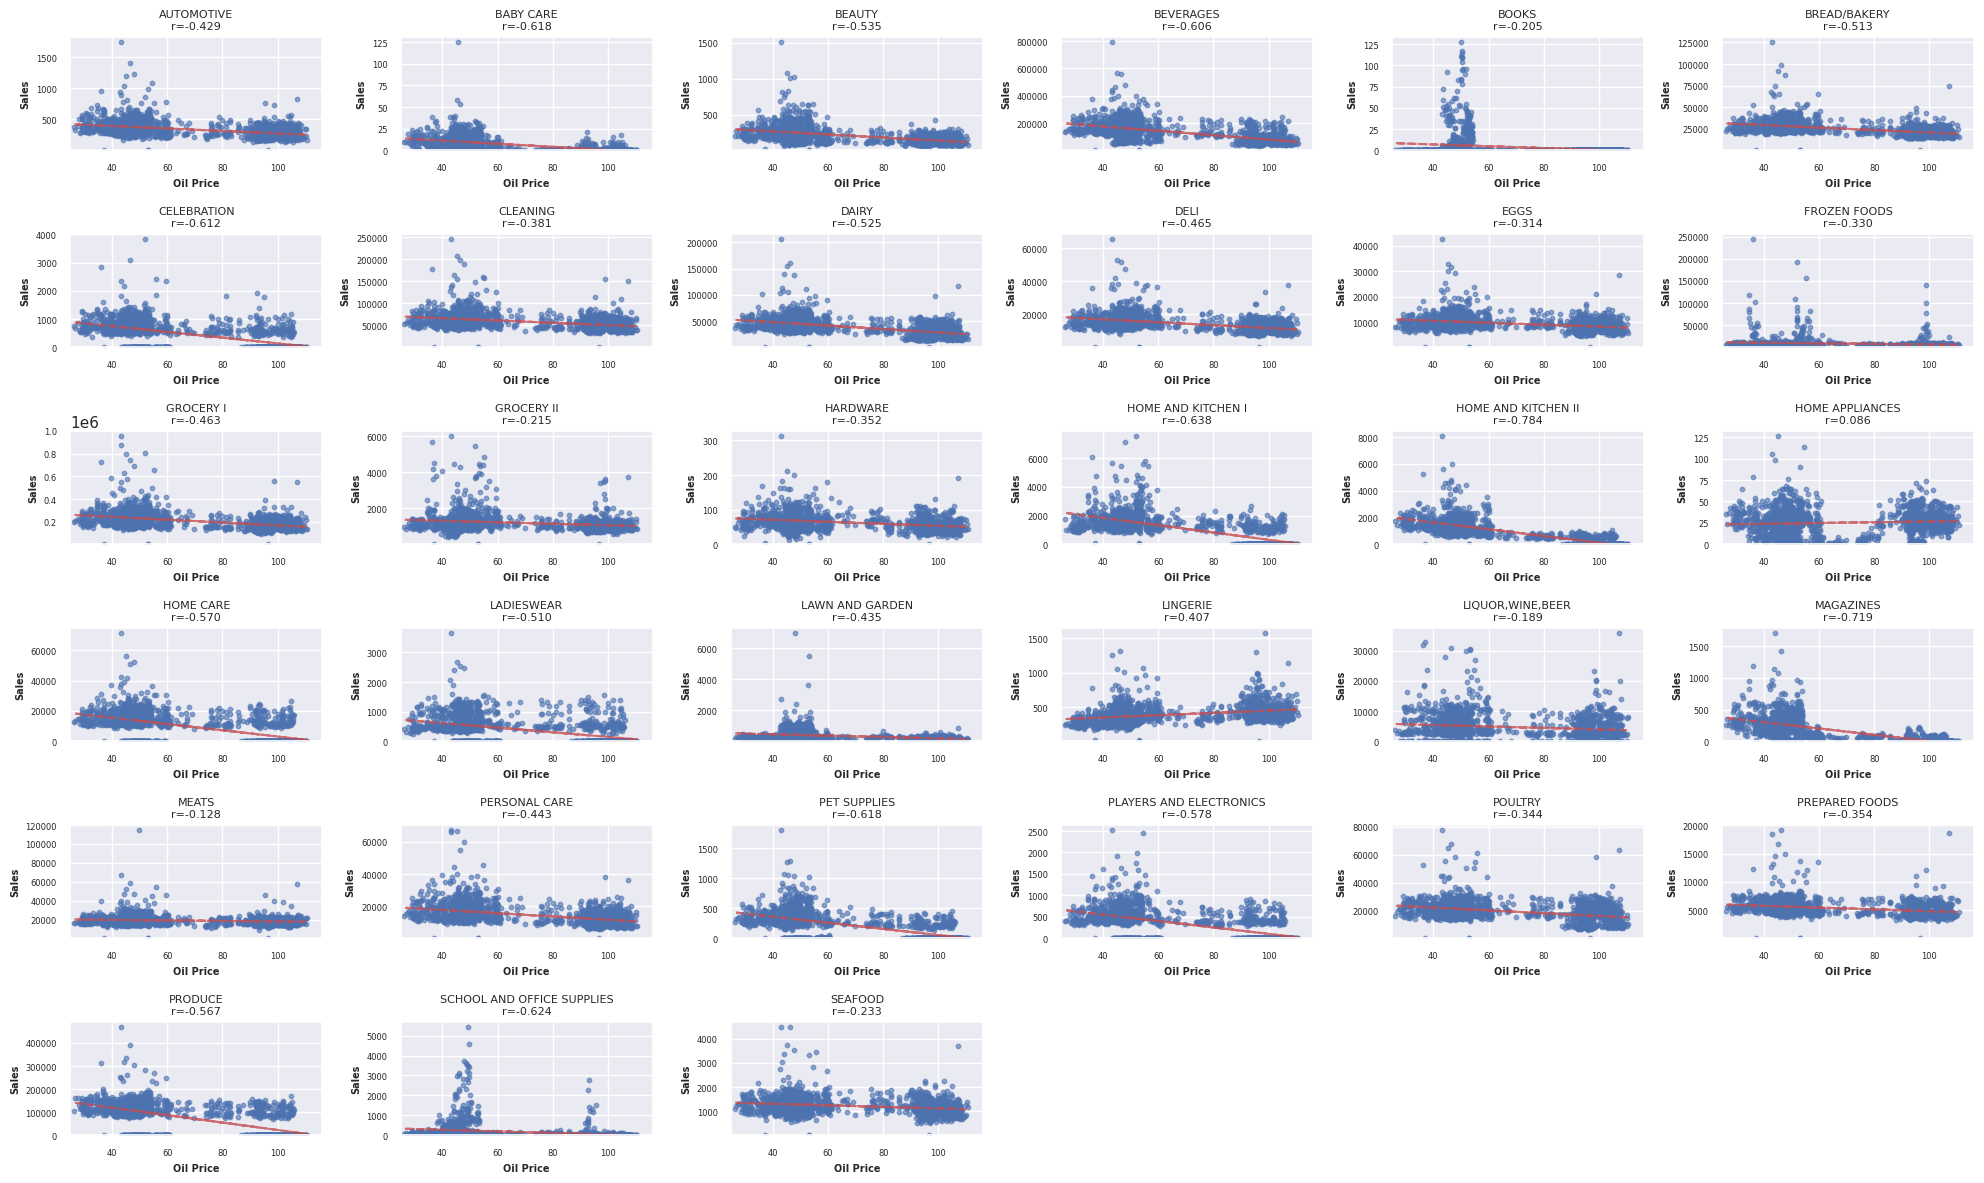

In [460]:
import math

daily_oil_with_family_sales = pd.merge(
    train.groupby(['date', 'family']).sales.sum().reset_index(), 
    daily_oil.drop('dcoilwtico', axis=1), 
    how='left'
)

family = daily_oil_with_family_sales['family'].unique()
family_corr = daily_oil_with_family_sales.groupby('family').corr('spearman').reset_index()
family_corr = family_corr[family_corr.level_1 == "dcoilwtico_interpolated"][["family", "sales"]].sort_values("sales")

n_cols = 6
n_rows = math.ceil(len(family) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 2 * n_rows))
axes = axes.flatten()

for i, fam in enumerate(family):
    ax = axes[i]
    # Get data for this family
    family_data = daily_oil_with_family_sales[daily_oil_with_family_sales['family'] == fam]
    
    # Remove NaN values
    clean_data = family_data.dropna(subset=['dcoilwtico_interpolated', 'sales'])
    
    if len(clean_data) > 0:
        # Create scatter plot
        ax.scatter(clean_data['dcoilwtico_interpolated'], clean_data['sales'], 
                   alpha=0.6, s=10)
        
        # Add trend line only if we have enough data and sufficient variation
        if len(clean_data) > 2:  # Need at least 3 points
            try:
                # Check if there's variation in oil prices
                if clean_data['dcoilwtico_interpolated'].std() > 1e-10:
                    z = np.polyfit(clean_data['dcoilwtico_interpolated'], clean_data['sales'], 1)
                    p = np.poly1d(z)
                    ax.plot(clean_data['dcoilwtico_interpolated'], 
                            p(clean_data['dcoilwtico_interpolated']), "r--", alpha=0.8)
            except (np.linalg.LinAlgError, np.RankWarning):
                # Skip trend line if polyfit fails
                pass
    
    # Get correlation for title - handle case where family might not exist in correlation data
    try:
        corr_val = family_corr[family_corr['family'] == fam]['sales'].iloc[0]
        ax.set_title(f'{fam}\nr={corr_val:.3f}', fontsize=8)
    except (IndexError, KeyError):
        ax.set_title(f'{fam}\nr=N/A', fontsize=8)
    
    ax.set_xlabel('Oil Price', fontsize=7)
    ax.set_ylabel('Sales', fontsize=7)
    ax.tick_params(labelsize=6)
    
    # Set reasonable axis limits if data exists
    if len(clean_data) > 0:
        ax.set_xlim(clean_data['dcoilwtico_interpolated'].min() * 0.95, 
                   clean_data['dcoilwtico_interpolated'].max() * 1.05)
        ax.set_ylim(clean_data['sales'].min() * 0.95, 
                   clean_data['sales'].max() * 1.05)

# Hide unused axes
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

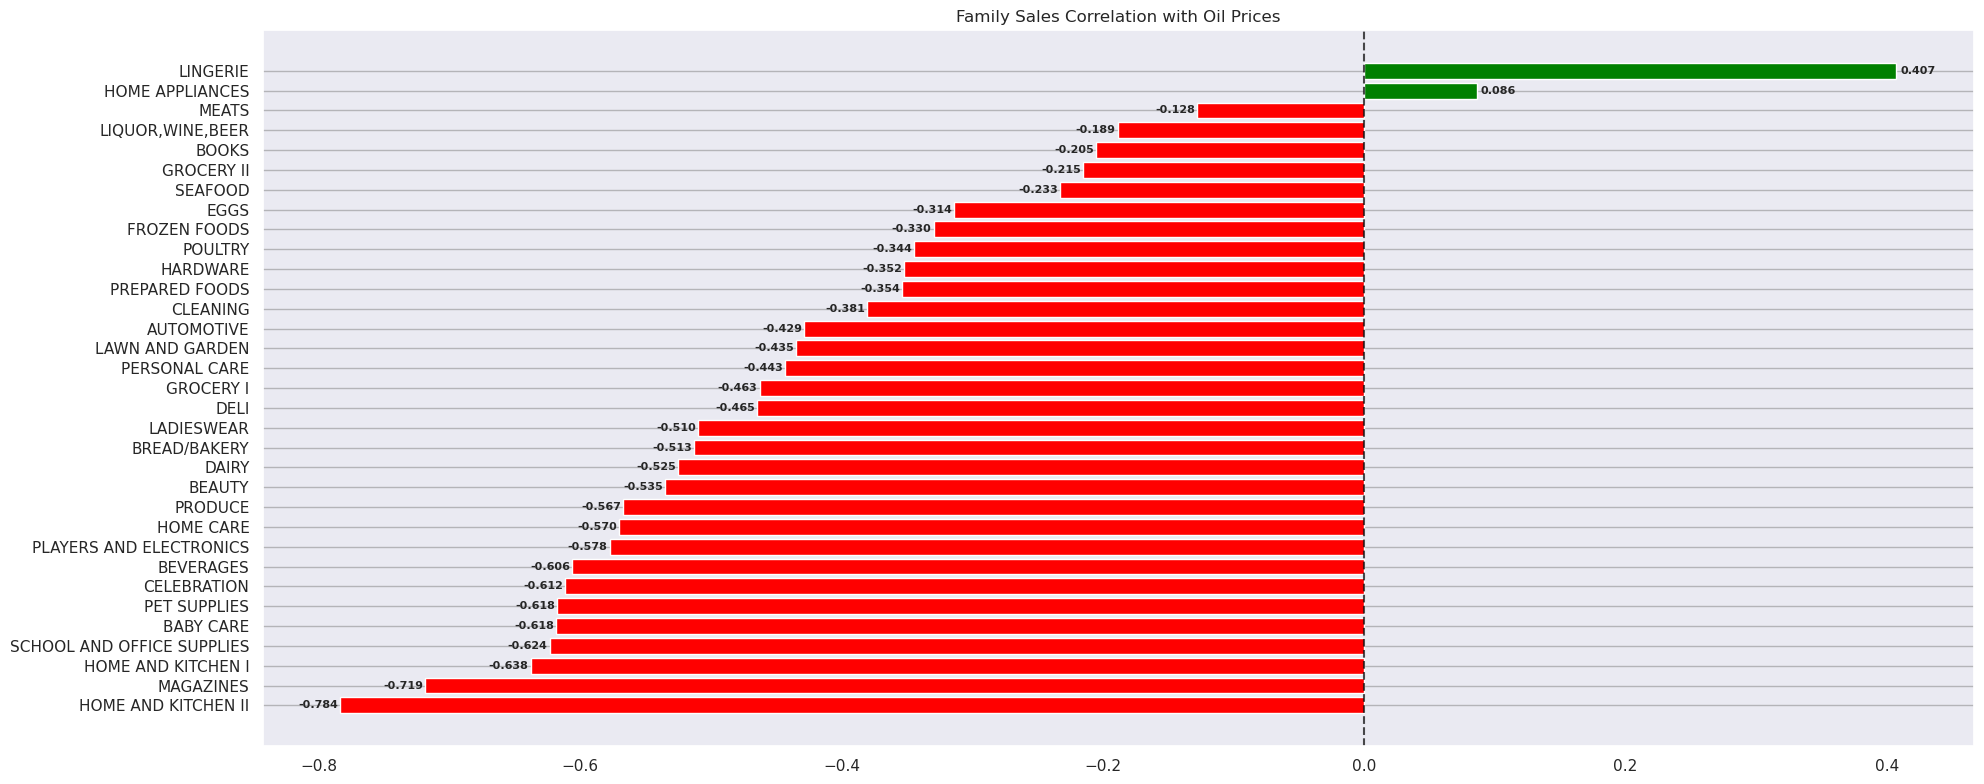

In [461]:
plt.figure(figsize=(20, 8))
color = ['red' if x < 0 else 'green' for x in family_corr['sales']]
plt.barh(range(len(family_corr)), family_corr['sales'], color=color)
plt.yticks(range(len(family_corr)), family_corr['family'])
plt.xlabel('')
plt.title('Family Sales Correlation with Oil Prices')

# Add correlation values as text
for i, (idx, row) in enumerate(family_corr.iterrows()):
    plt.text(row['sales'] + 0.0030 if row['sales'] >= 0 else row['sales'] - 0.032, 
             i, f'{row["sales"]:.3f}', 
             va='center', fontweight='bold', fontsize=8)

plt.axvline(x=0, color='black', linestyle='--', alpha=0.7)
plt.grid(axis='x', alpha=0.0, color='grey')
plt.grid(axis='y', alpha=0.5, color='grey')
plt.tight_layout()
plt.show()

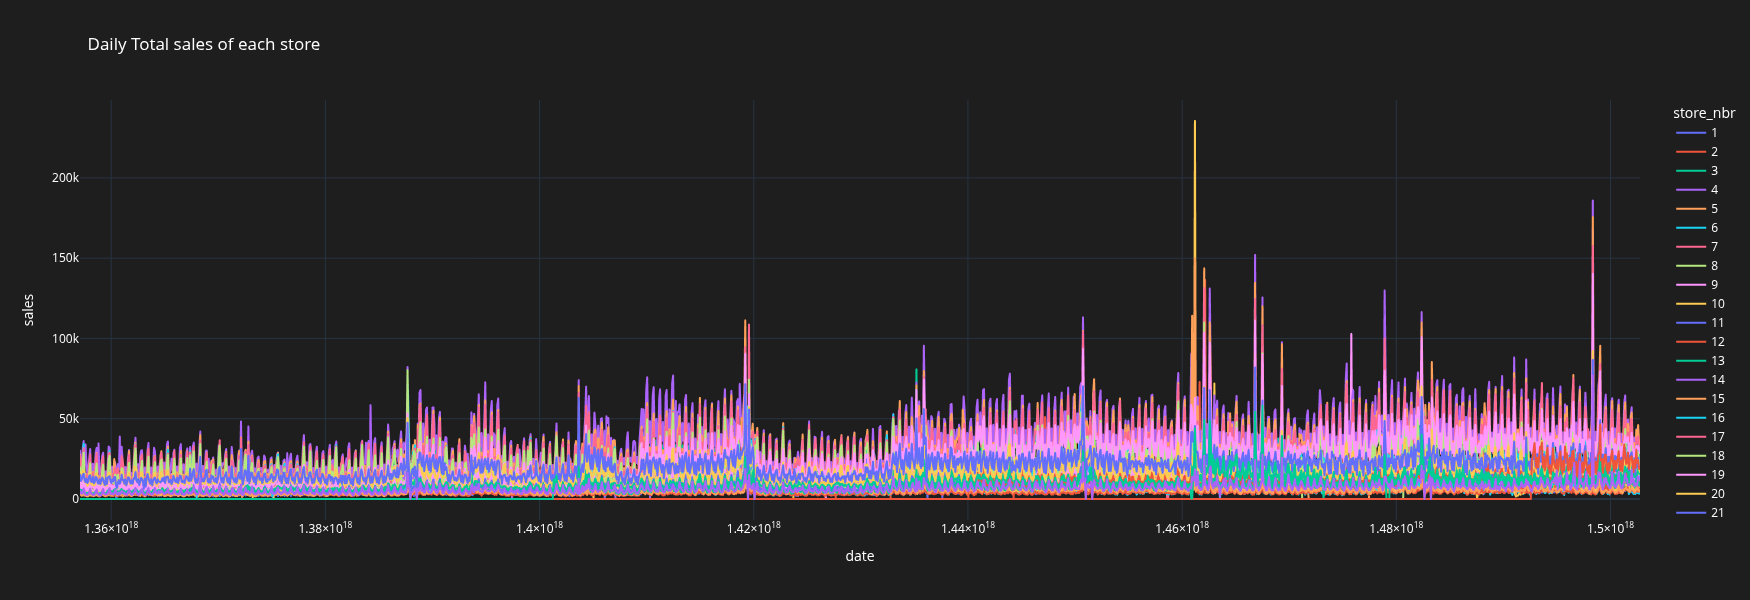

In [462]:
daily_total_sales = train.set_index('date').groupby('store_nbr').resample('D').sales.sum().reset_index()
fig = px.line(daily_total_sales,
        x='date', y='sales',
        color='store_nbr', title='Daily Total sales of each store',
        template='plotly_dark')
fig.show()

In [463]:
sales_per_store = daily_total_sales.groupby(['date', 'store_nbr']).agg({
    'sales':'sum'
})

store_with_no_sales = sales_per_store[sales_per_store.sales == 0]

display(sales_per_store)
display(store_with_no_sales)

sales
date       store_nbr              
2013-01-02 1           7417.148000
           2          10266.718981
           3          24060.348000
           4          10200.083980
           5          10598.619020
...                            ...
2017-08-15 50         16879.121004
           51         20154.559000
           52         18600.046000
           53          8208.189000
           54         12666.858000

[91098 rows x 1 columns]

sales
date       store_nbr       
2013-01-02 20           0.0
           21           0.0
           22           0.0
           29           0.0
           36           0.0
...                     ...
2017-04-15 52           0.0
2017-04-16 52           0.0
2017-04-17 52           0.0
2017-04-18 52           0.0
2017-04-19 52           0.0

[7493 rows x 1 columns]

In [464]:
mask = ~train.set_index(['date', 'store_nbr']).index.isin(store_with_no_sales.index)
train_ = train[mask]

In [466]:
# Verify: these store-date combinations should have total sales > 0
verification = train_.groupby(['date', 'store_nbr'])['sales'].sum()
print(f"Any zero total sales remaining: {(verification == 0).any()}")  # Should be False

# Compare row counts
print(f"Original rows: {len(train)}")
print(f"Filtered rows: {len(train_)}")
print(f"Removed rows: {len(train) - len(train_)}")

Any zero total sales remaining: False
Original rows: 3052566
Filtered rows: 2809092
Removed rows: 243474


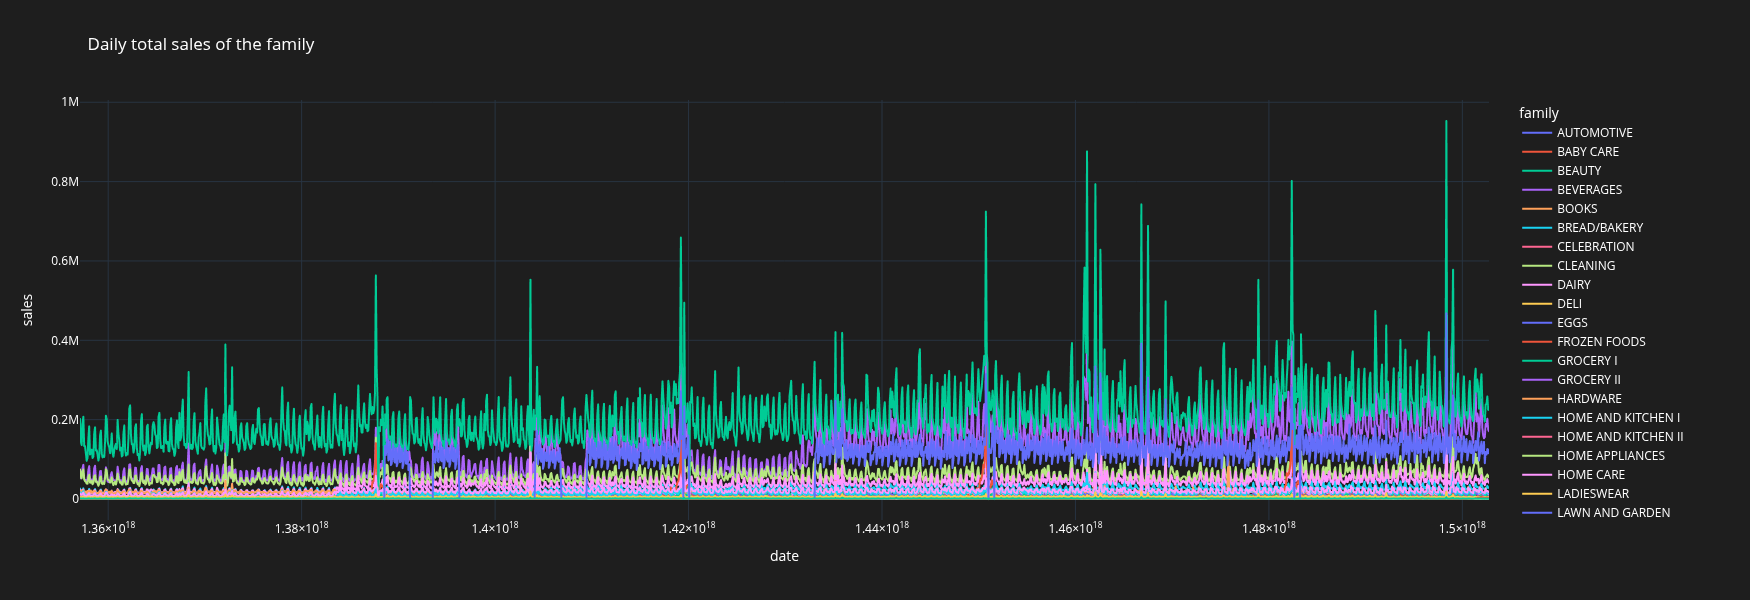

In [467]:
family_daily_total_sales = train_.set_index("date").groupby("family").resample("D").sales.sum().reset_index()
fig = px.line(family_daily_total_sales, x = "date", y= "sales", color = "family", title = "Daily total sales of the family", template='plotly_dark')
fig.show()

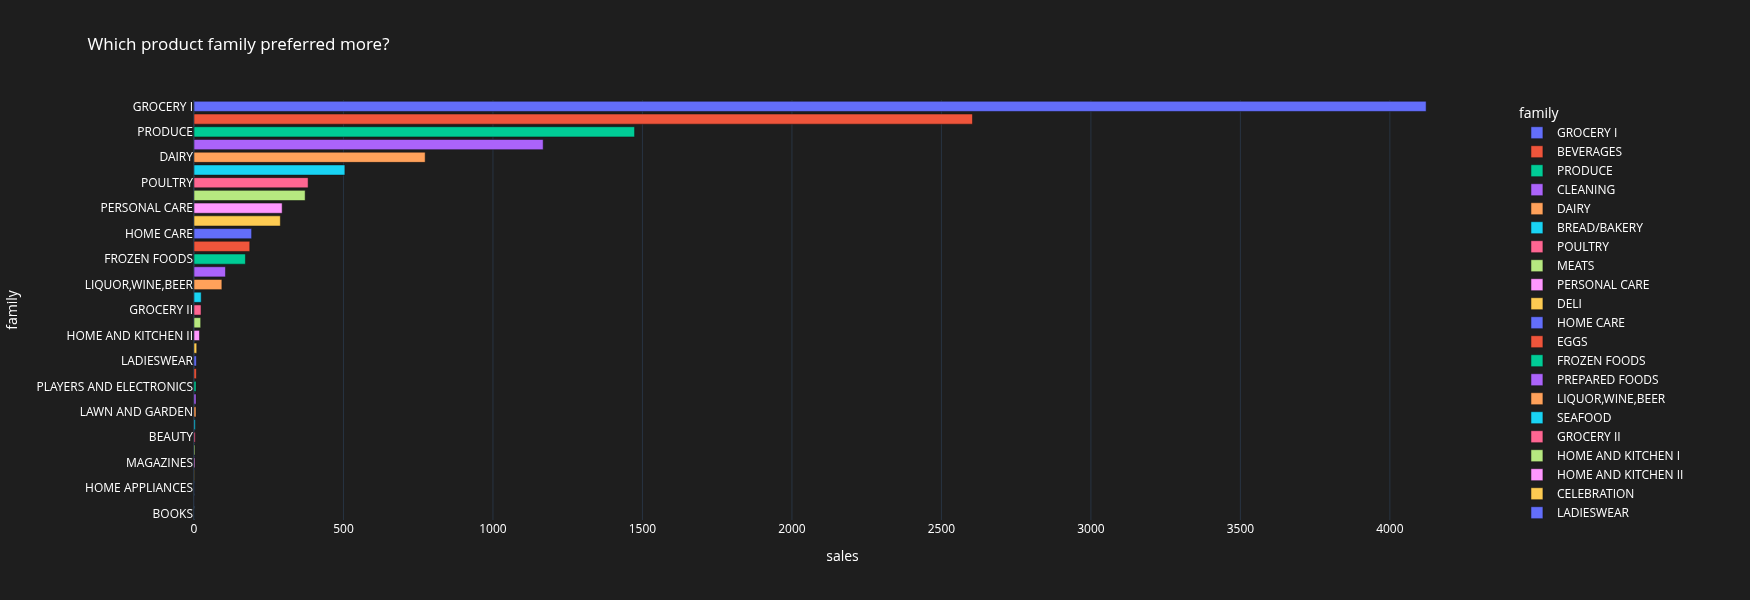

In [468]:
preferred_product = train_.groupby("family").sales.mean().sort_values(ascending = False).reset_index()
fig = px.bar(preferred_product, y = "family", x="sales",
       color = "family", title = "Which product family preferred more?",
       template='plotly_dark')
fig.show()

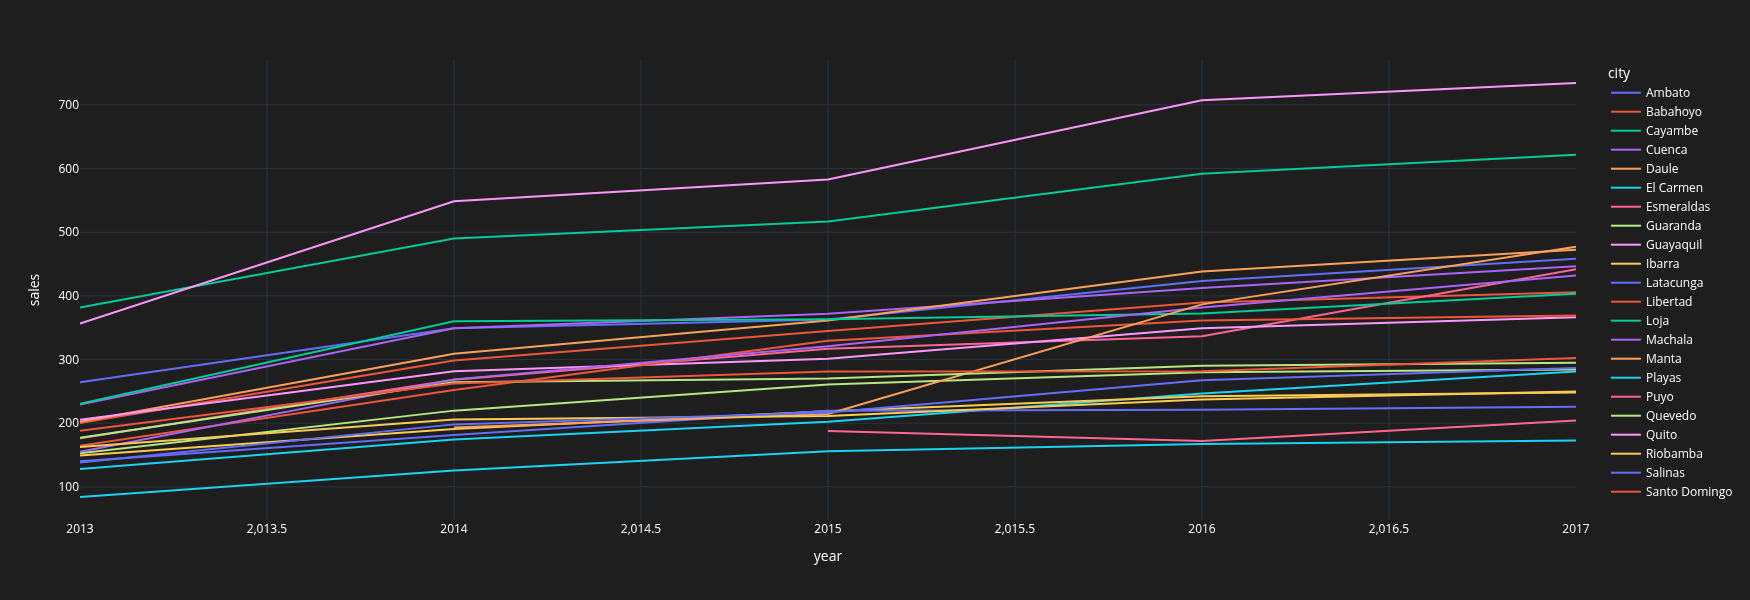

In [469]:
store_city = pd.merge(train_, stores)
store_city['year'] = store_city.date.dt.year
fig = px.line(store_city.groupby(["city", "year"]).sales.mean().reset_index(), x = "year", y = "sales",
        color = "city", template='plotly_dark')
fig.show()

In [470]:
grouping_columns = ['year', 'quarter', 'month', 'day_of_week', 'day_of_year', 'day_of_month']

for ind, column in enumerate(grouping_columns):
    grouped_data = train.groupby(column)['sales'].sum()
    grouped_data = pd.DataFrame(grouped_data).reset_index()
    
data_ = data.copy().reset_index()
grouped_data = data_.groupby(['store_nbr', 'family'])

In [475]:
alphas = [0.95, 0.8, 0.65, 0.5]
lags =[1,7,30]

for a in alphas:
    for i in lags:
        data_[f'sales_lag_{i}_alpha_{a}'] = np.log1p(grouped_data['sales'].transform(lambda x: x.shift(i).ewm(alpha=a, min_periods=1).mean()))
        
data_['date'] = pd.to_datetime(data_["date"])
data_['day_of_week'] = data_['date'].dt.day_of_week
data_['day_of_year'] = data_['date'].dt.dayofyear
data_['day_of_month'] = data_['date'].dt.day
data_['month'] = data_['date'].dt.month
data_['quarter'] = data_['date'].dt.quarter
data_['year'] = data_['date'].dt.year

data_['onpromotion'] = data_['onpromotion'].apply(lambda x: x > 0)
sales_lag_columns = list(data_.filter(like="lag").columns)

In [478]:
import re

training_percentage = 0.8
testing_percentage = 0.2

to_dummies = ['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'store_nbr', 'type_y', 'cluster', 'family', 'onpromotion', 'type_x',
       'locale', 'locale_name', 'city', 'state']

X = data_.loc[:, [ 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'store_nbr', 'type_y', 'cluster', 'family', 'onpromotion', 'type_x',
       'locale', 'locale_name',  'city', 'state', 'test', 'sales', 'id']+ sales_lag_columns]
X[to_dummies] = X[to_dummies].astype('category')

data_train = X[X['test'] == 0]
data_test = X[X['test'] == 1]

n = len(data_train)

training_start = 0
training_end = math.floor(n * training_percentage)
validation_start = training_end
validation_end = n

X_train = data_train.loc[training_start:training_end, :].drop(['test', 'sales', 'id'],  axis=1)
y_train = data_train.loc[training_start:training_end, 'sales']
X_val = data_train.loc[validation_start:validation_end,  :].drop(['test', 'sales', 'id'],  axis=1)
y_val = data_train.loc[validation_start:validation_end, 'sales']

X_test = data_test.loc[:, ].drop(['test', 'sales', 'id'],  axis=1)

X_train = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x)) 
X_val = X_val.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x)) 
X_test = X_test.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x)) 

In [480]:
import lightgbm as lgb

hyper_params = {'task': 'train','boosting_type': 'gbdt','objective': 'regression','metric': ['l1','l2'],'learning_rate': 0.1,
'feature_fraction': 0.9,'bagging_fraction': 0.7,'bagging_freq': 10,'verbose': 0,"max_depth": 50,"num_leaves": 128,"max_bin": 512}

gbm = lgb.LGBMRegressor(**hyper_params)

gbm.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='l1')

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10
[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_fr

,boosting_type,'gbdt'
,num_leaves,128
,max_depth,50
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [481]:
y_pred = gbm.predict(X_val)

[LightGBM] [Warning] feature_fraction is set=0.9, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9
[LightGBM] [Warning] bagging_fraction is set=0.7, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7
[LightGBM] [Warning] bagging_freq is set=10, subsample_freq=0 will be ignored. Current value: bagging_freq=10


In [485]:
results = pd.concat([y_val.reset_index(drop=True), pd.Series(y_pred)], axis=1).rename(columns={'sales': 'y_val', 0: 'y_pred'})
results['y_pred'] = results['y_pred'].clip(0)
results = results[results['y_val'] > 10]
results

,y_val,y_pred
3,19.000,106.410473
5,119.630,121.568432
6,181.000,255.618499
9,165.181,191.744160
10,95.198,79.172090
...,...,...
610509,438.133,343.113848
610510,154.553,119.901681
610511,2419.729,2109.172875
610512,121.000,170.938767


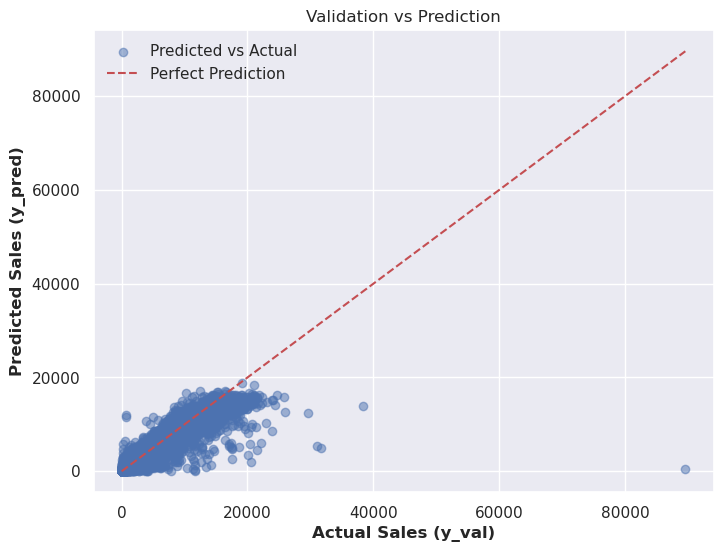

In [486]:
import matplotlib.pyplot as plt

# Scatter plot of validation vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(results['y_val'], results['y_pred'], alpha=0.5, label='Predicted vs Actual')

# Optional: plot a reference line y = x to visualize perfect predictions
plt.plot([results['y_val'].min(), results['y_val'].max()],
         [results['y_val'].min(), results['y_val'].max()], 'r--', label='Perfect Prediction')

plt.xlabel('Actual Sales (y_val)')
plt.ylabel('Predicted Sales (y_pred)')
plt.title('Validation vs Prediction')
plt.legend()
plt.grid(True)
plt.show()


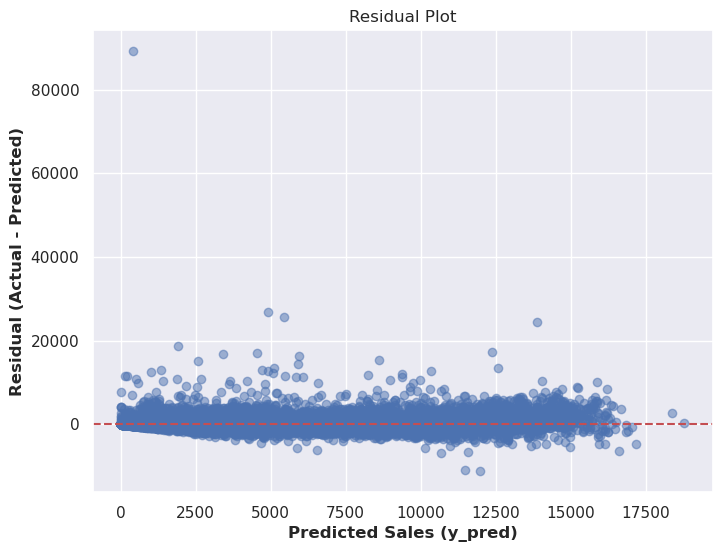

In [487]:
results['residual'] = results['y_val'] - results['y_pred']

plt.figure(figsize=(8, 6))
plt.scatter(results['y_pred'], results['residual'], alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Sales (y_pred)')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

MAE: 112.62
RMSE: 386.36
R²: 0.947


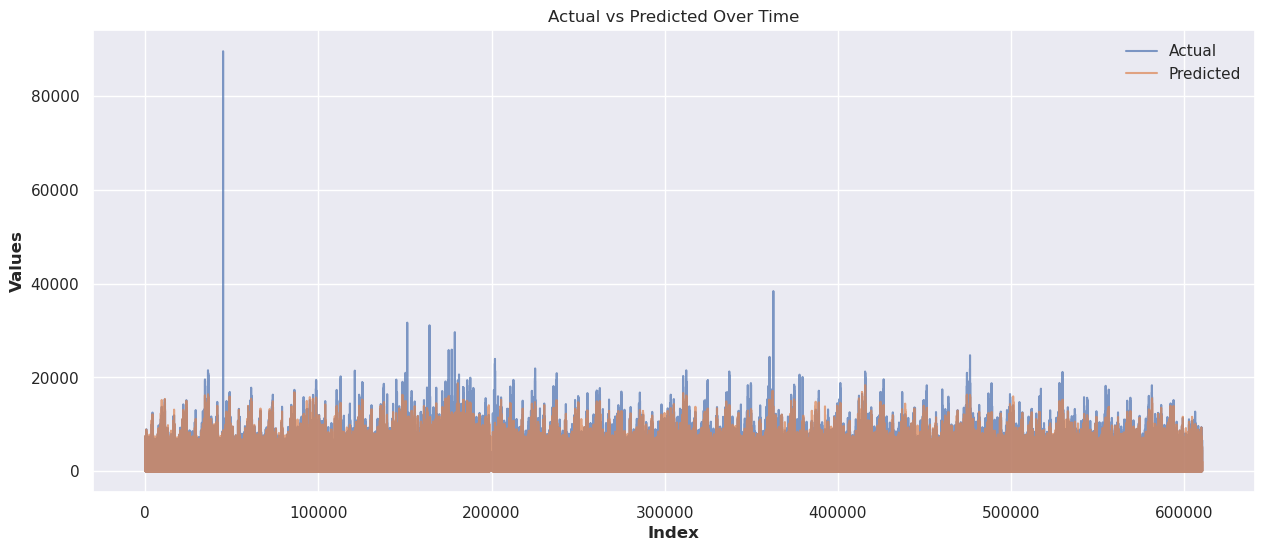

In [492]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(results['y_val'], results['y_pred'])
rmse = np.sqrt(mean_squared_error(results['y_val'], results['y_pred']))
r2 = r2_score(results['y_val'], results['y_pred'])

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}') 
print(f'R²: {r2:.3f}')

plt.figure(figsize=(15, 6))
plt.plot(results.index, results['y_val'], label='Actual', alpha=0.7)
plt.plot(results.index, results['y_pred'], label='Predicted', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Values')
plt.title('Actual vs Predicted Over Time')
plt.legend()
plt.show()